In [67]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Продуктовая аналитика: Поиск точек роста бизнеса

### Ключевые показатели юнит-экономики:

- UA (User Acquisition) — Общее количество входящих лидов.
- C1 (Conversion Rate) — Конверсия из лида в уникального покупателя (B/UA).
- B (Buyers) — Количество уникальных подтверждённых покупателей.
- T (Transactions) — Общее количество подтверждённых сделок (оплат).
- Rev (Revenue) — Выручка (сумма начальных платежей подтверждённых покупателей).
- APC (Average Purchase Count) — Среднее количество покупок на одного покупателя (T/B).
- AOV (Average Order Value) — Средний чек за транзакцию (Rev/T).
- AC (Acquisition Cost) — Общие маркетинговые затраты.
- CAC (Customer Acquisition Cost) — Стоимость привлечения одного покупателя (AC/B).
- CPA (Cost Per Acquisition/Lead) — Стоимость одного лида (AC/UA). В коде часто LTC.
- CLTV (Customer Lifetime Value) — Доход от одного покупателя.
- LTV (Lifetime Value) — Доход от одного привлеченного лида.
- CM (Contribution Margin) — Маржинальная прибыль (Rev - AC).

Изменяемые рычаги для анализа чувствительности: UA, C1, APC, AOV, LTC.

### Импорт и загрузка

In [30]:
data_dir = r"C:\Users\Admin\Desktop\ICH\Учеба, курсы в записи, домашки\Финальный проект\дополнительные файлы"

analytics_base_path = os.path.join(data_dir, "analytics_base.csv")
spend_path = os.path.join(data_dir, "spend_clean.csv")
contacts_path = os.path.join(data_dir, "contacts_clean.csv")

analytics_base = pd.read_csv(analytics_base_path, dtype={"id": "string", "contact_id": "string"})

spend = pd.read_csv(spend_path)

contacts = pd.read_csv(contacts_path, dtype={"id": "string"})

### Подготовка типов

In [31]:
analytics_base["is_student"] = (analytics_base["is_student"].astype(str).str.strip().str.lower().isin(["true", "1"]))

numeric_columns = [
    "initial_amount_paid",
    "offer_total_amount",
    "course_duration",
    "months_of_study"]

for col in numeric_columns:
    analytics_base[col] = pd.to_numeric(analytics_base[col], errors="coerce")

spend["spend"] = pd.to_numeric(spend["spend"], errors="coerce")

### Базовые показатели

In [32]:
students = analytics_base[analytics_base["is_student"] == True].copy()

ua = contacts["id"].nunique()

student_deals = len(students)

buyers = students["contact_id"].nunique()

ac = spend["spend"].sum()

print("UA / уникальные контакты:", ua)
print("Student deals / строк студентов:", student_deals)
print("B / уникальные студенты:", buyers)
print("AC / расходы на маркетинг:", round(ac, 2))

UA / уникальные контакты: 18510
Student deals / строк студентов: 840
B / уникальные студенты: 828
AC / расходы на маркетинг: 149523.45


### Готовим студентов для расчета выручки

In [33]:
unit_students = students[(students["months_of_study"] > 0)
    & (students["initial_amount_paid"].notna())
    & (students["offer_total_amount"].notna())
    & (students["course_duration"].notna())].copy()

excluded_from_revenue = len(students) - len(unit_students)

print("Строк студентов всего:", len(students))
print("Строк студентов в расчете выручки:", len(unit_students))
print("Исключено из расчета выручки:", excluded_from_revenue)

Строк студентов всего: 840
Строк студентов в расчете выручки: 839
Исключено из расчета выручки: 1


### Защита от отрицательных значений

In [34]:
# Здесь логика такая: если вдруг initial_amount_paid больше offer_total_amount, мы не получаем отрицательный остаток. Для расчета берем цену курса не ниже первого платежа.
unit_students["initial_paid_for_calc"] = (unit_students["initial_amount_paid"].clip(lower=0))

unit_students["course_price_for_calc"] = (unit_students[["offer_total_amount", "initial_paid_for_calc"]].max(axis=1).clip(lower=0))

unit_students["remaining_amount"] = (unit_students["course_price_for_calc"] - unit_students["initial_paid_for_calc"]).clip(lower=0)

### Справедливая выручка и AOV

In [35]:
unit_students["monthly_payment_after_first"] = np.where(
    unit_students["course_duration"] > 1,
    unit_students["remaining_amount"] / (unit_students["course_duration"] - 1), 0)

unit_students["months_after_first"] = (unit_students["months_of_study"] - 1).clip(lower=0)

unit_students["fair_revenue"] = (
    unit_students["initial_paid_for_calc"]
    + unit_students["monthly_payment_after_first"]
    * unit_students["months_after_first"])

unit_students["fair_revenue"] = np.minimum( unit_students["fair_revenue"], unit_students["course_price_for_calc"])

unit_students["fair_revenue"] = (unit_students["fair_revenue"].replace([np.inf, -np.inf], np.nan).clip(lower=0))

unit_students["fair_aov"] = (unit_students["fair_revenue"] / unit_students["months_of_study"])

unit_students["fair_aov"] = (unit_students["fair_aov"].replace([np.inf, -np.inf], np.nan).clip(lower=0))

### Проверка

In [36]:
unit_students[[
    "id",
    "contact_id",
    "product",
    "months_of_study",
    "course_duration",
    "initial_amount_paid",
    "offer_total_amount",
    "course_price_for_calc",
    "monthly_payment_after_first",
    "fair_revenue",
    "fair_aov"]].head(10)

,id,contact_id,product,months_of_study,course_duration,initial_amount_paid,offer_total_amount,course_price_for_calc,monthly_payment_after_first,fair_revenue,fair_aov
9,5805028000000947046,5805028000000939010,Digital Marketing,11.0,11.0,1000.0,11000.0,11000.0,1000.0,11000.0,1000.000000
61,5805028000001401001,5805028000001350049,Digital Marketing,8.0,11.0,1000.0,11500.0,11500.0,1050.0,8350.0,1043.750000
103,5805028000026485283,5805028000001404153,Digital Marketing,4.0,11.0,300.0,4000.0,4000.0,370.0,1410.0,352.500000
225,5805028000001885076,5805028000001880249,Digital Marketing,11.0,11.0,450.0,4000.0,4000.0,355.0,4000.0,363.636364
233,5805028000028609025,5805028000001882098,Digital Marketing,6.0,11.0,1000.0,11000.0,11000.0,1000.0,6000.0,1000.000000
261,5805028000001987082,5805028000001986077,Digital Marketing,11.0,11.0,1000.0,11000.0,11000.0,1000.0,11000.0,1000.000000
281,5805028000004863088,5805028000002100030,Digital Marketing,11.0,11.0,1000.0,11500.0,11500.0,1050.0,11500.0,1045.454545
290,5805028000021790015,5805028000002150769,Web Developer,6.0,6.0,200.0,2000.0,2000.0,360.0,2000.0,333.333333
316,5805028000002302112,5805028000002302109,Web Developer,2.0,6.0,1000.0,5000.0,5000.0,800.0,1800.0,900.000000
328,5805028000002306176,5805028000002333161,Digital Marketing,7.0,11.0,350.0,3500.0,3500.0,315.0,2240.0,320.000000


In [37]:
unit_students[["fair_revenue", "fair_aov", "monthly_payment_after_first"]].describe()

,fair_revenue,fair_aov,monthly_payment_after_first
count,839.000000,839.000000,839.000000
mean,4268.623361,873.630388,696.233611
std,2944.561780,780.499139,384.634622
min,0.000000,0.000000,0.000000
25%,2000.000000,369.000000,360.000000
50%,3350.000000,1000.000000,1000.000000
75%,6250.000000,1000.000000,1000.000000
max,11500.000000,11000.000000,1600.000000


In [38]:
unit_students[(unit_students["fair_revenue"] < 0) | (unit_students["fair_aov"] < 0) | (unit_students["monthly_payment_after_first"] < 0)]

,id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,content,...,total_call_duration_sec,first_call_time,last_call_time,initial_paid_for_calc,course_price_for_calc,remaining_amount,monthly_payment_after_first,months_after_first,fair_revenue,fair_aov


### Общая юнит-экономика

In [39]:
# T — расчетные платежные периоды, то есть сумма месяцев обучения;
# AOV = Rev / T;
# APC = T / B;
# CLTV = AOV * APC

rev = unit_students["fair_revenue"].sum()
t = unit_students["months_of_study"].sum()
c1 = buyers / ua
aov = rev / t
apc = t / buyers
cltv = aov * apc
ltv = c1 * cltv
cac = ac / buyers
cpl = ac / ua
cm = rev - ac
romi = (cm / ac) * 100
roas = rev / ac

### Итоговая таблица

In [40]:
unit_economics_summary = pd.DataFrame({
    "metric": [
        "UA / уникальные контакты",
        "B / уникальные покупатели",
        "Student deals / строк студентов",
        "Excluded from revenue / исключено из расчета",
        "T / расчетные платежные периоды",
        "C1 / конверсия в покупателя",
        "Rev / справедливая выручка",
        "AOV / средний месячный чек",
        "APC / среднее количество платежных периодов",
        "CLTV / выручка на покупателя",
        "LTV / выручка на пользователя",
        "AC / маркетинговые расходы",
        "CAC / стоимость привлечения покупателя",
        "CPL / стоимость привлечения лида",
        "CM / contribution margin",
        "ROAS / выручка к расходам",
        "ROMI / окупаемость маркетинга"],
    "value": [
        ua,
        buyers,
        student_deals,
        excluded_from_revenue,
        t,
        c1,
        rev,
        aov,
        apc,
        cltv,
        ltv,
        ac,
        cac,
        cpl,
        cm,
        roas,
        romi]})

unit_economics_summary

,metric,value
0,UA / уникальные контакты,1.851000e+04
1,B / уникальные покупатели,8.280000e+02
2,Student deals / строк студентов,8.400000e+02
3,Excluded from revenue / исключено из расчета,1.000000e+00
4,T / расчетные платежные периоды,4.572000e+03
5,C1 / конверсия в покупателя,4.473258e-02
6,Rev / справедливая выручка,3.581375e+06
7,AOV / средний месячный чек,7.833279e+02
8,APC / среднее количество платежных периодов,5.521739e+00
9,CLTV / выручка на покупателя,4.325332e+03


In [42]:
# выводим красиво
unit_economics_summary_formatted = unit_economics_summary.copy()
unit_economics_summary_formatted["value"] = [
    f"{ua:,.0f}",
    f"{buyers:,.0f}",
    f"{student_deals:,.0f}",
    f"{excluded_from_revenue:,.0f}",
    f"{t:,.0f}",
    f"{c1:.2%}",
    f"{rev:,.2f}",
    f"{aov:,.2f}",
    f"{apc:,.2f}",
    f"{cltv:,.2f}",
    f"{ltv:,.2f}",
    f"{ac:,.2f}",
    f"{cac:,.2f}",
    f"{cpl:,.2f}",
    f"{cm:,.2f}",
    f"{roas:.2f}",
    f"{romi:.2f}%"]
unit_economics_summary_formatted

,metric,value
0,UA / уникальные контакты,"18,510"
1,B / уникальные покупатели,828
2,Student deals / строк студентов,840
3,Excluded from revenue / исключено из расчета,1
4,T / расчетные платежные периоды,"4,572"
5,C1 / конверсия в покупателя,4.47%
6,Rev / справедливая выручка,"3,581,375.00"
7,AOV / средний месячный чек,783.33
8,APC / среднее количество платежных периодов,5.52
9,CLTV / выручка на покупателя,"4,325.33"


# Вывод по общей юнит-экономике
В общей модели были рассчитаны ключевые показатели юнит-экономики: количество пользователей, количество студентов, конверсия в студента, справедливая выручка, средний месячный чек, среднее количество месяцев обучения, CLTV, LTV, CAC, CPL и ROMI.

Пользователями были приняты уникальные контакты из таблицы Contacts. Покупателями были приняты уникальные студенты по contact_id, так как один контакт может иметь больше одной сделки. Отдельно было показано количество строк студентов, чтобы сохранить связь с исходной таблицей сделок.

Маркетинговые расходы учитывались полностью, потому что реклама привлекала весь поток лидов, а не только тех, кто стал студентом. Поэтому CAC показывает среднюю стоимость привлечения одного уникального студента с учетом всех рекламных расходов.

Средний чек был рассчитан по согласованной формуле, которая учитывает первый платеж, полную стоимость курса, длительность курса и количество месяцев обучения. Такой подход позволяет более справедливо оценить выручку, особенно если первый платеж отличается от равномерного ежемесячного платежа.

Одна строка студента была исключена из расчета AOV, так как значение months_of_study равно нулю. Такая строка не удалялась из данных полностью, но не могла участвовать в расчете среднего месячного чека, потому что формула делит выручку на количество месяцев обучения.

Полученные метрики показывают, сколько в среднем стоит привлечь одного студента, сколько денег приносит один студент за период обучения и насколько в целом окупаются маркетинговые расходы. Эта модель будет базой для дальнейшего анализа юнит-экономики по продуктам и источникам.

# Юнит-экономика по продуктам
Считаем ключевые метрики, но в разрезе product:
- сколько лидов пришло на каждый продукт;
- сколько студентов;
- какая конверсия;
- какая справедливая выручка;
- AOV;
- APC;
- CLTV;
- доля выручки;
- доля студентов.

#### Готовим выручку студентов по продуктам

In [43]:
student_revenue_by_product = (unit_students.groupby("product", dropna=False)
    .agg(
        buyers=("contact_id", "nunique"),
        student_deals=("id", "count"),
        payment_periods=("months_of_study", "sum"),
        revenue=("fair_revenue", "sum")).reset_index())

#### Считаем лиды по продуктам

In [44]:
leads_by_product = (analytics_base.groupby("product", dropna=False).agg(
        users=("contact_id", "nunique"),
        deals_count=("id", "count")).reset_index())

#### Объединяем лиды и студентов

In [45]:
product_unit = leads_by_product.merge(student_revenue_by_product, on="product", how="left")

product_unit[[
    "buyers",
    "student_deals",
    "payment_periods",
    "revenue"
]] = product_unit[[
    "buyers",
    "student_deals",
    "payment_periods",
    "revenue"
]].fillna(0)

#### Считаем метрики по продуктам

In [46]:
# Это общая картина метрик по всем продуктам
product_unit["c1"] = (product_unit["buyers"] / product_unit["users"].replace(0, np.nan))
product_unit["aov"] = (product_unit["revenue"] / product_unit["payment_periods"].replace(0, np.nan))
product_unit["apc"] = (product_unit["payment_periods"] / product_unit["buyers"].replace(0, np.nan))
product_unit["cltv"] = (product_unit["aov"] * product_unit["apc"])
product_unit["revenue_share"] = (product_unit["revenue"] / product_unit["revenue"].sum())
product_unit["buyers_share"] = (product_unit["buyers"] / product_unit["buyers"].sum())
product_unit = product_unit.sort_values("revenue", ascending=False)
product_unit

,product,users,deals_count,buyers,student_deals,payment_periods,revenue,c1,aov,apc,cltv,revenue_share,buyers_share
1,Digital Marketing,1924,2444,469.0,474.0,2897.0,2264850.0,0.243763,781.791508,6.176972,4829.104478,0.632397,0.565742
3,UX/UI Design,999,1216,225.0,228.0,1170.0,949945.0,0.225225,811.918803,5.200000,4221.977778,0.265246,0.271411
5,Web Developer,559,714,135.0,137.0,505.0,366580.0,0.241503,725.900990,3.740741,2715.407407,0.102357,0.162847
0,Data Analytics,1,1,0.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,0.000000,0.000000
2,Find yourself in IT,2,19,0.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,0.000000,0.000000
4,Unknown,13514,15430,0.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,0.000000,0.000000


In [47]:
# Эти продукты убираем из продуктовой юнит-экономики, потому что по ним мало данных или они не отражают полноценное направление обучения.
excluded_products = ["Data Analytics", "Find yourself in IT", "Unknown"]

product_unit = product_unit[~product_unit["product"].isin(excluded_products)].copy()

In [48]:
product_unit_formatted = product_unit.copy()

product_unit_formatted["c1"] = (product_unit_formatted["c1"] * 100).round(2)

product_unit_formatted["revenue_share"] = (product_unit_formatted["revenue_share"] * 100).round(2)

product_unit_formatted["buyers_share"] = (product_unit_formatted["buyers_share"] * 100).round(2)

round_columns = [
    "revenue",
    "aov",
    "apc",
    "cltv"]

for col in round_columns:
    product_unit_formatted[col] = product_unit_formatted[col].round(2)

product_unit_formatted[[
    "product",
    "users",
    "buyers",
    "student_deals",
    "payment_periods",
    "c1",
    "revenue",
    "aov",
    "apc",
    "cltv",
    "revenue_share",
    "buyers_share"]]

,product,users,buyers,student_deals,payment_periods,c1,revenue,aov,apc,cltv,revenue_share,buyers_share
1,Digital Marketing,1924,469.0,474.0,2897.0,24.38,2264850.0,781.79,6.18,4829.10,63.24,56.57
3,UX/UI Design,999,225.0,228.0,1170.0,22.52,949945.0,811.92,5.20,4221.98,26.52,27.14
5,Web Developer,559,135.0,137.0,505.0,24.15,366580.0,725.90,3.74,2715.41,10.24,16.28


### Графики

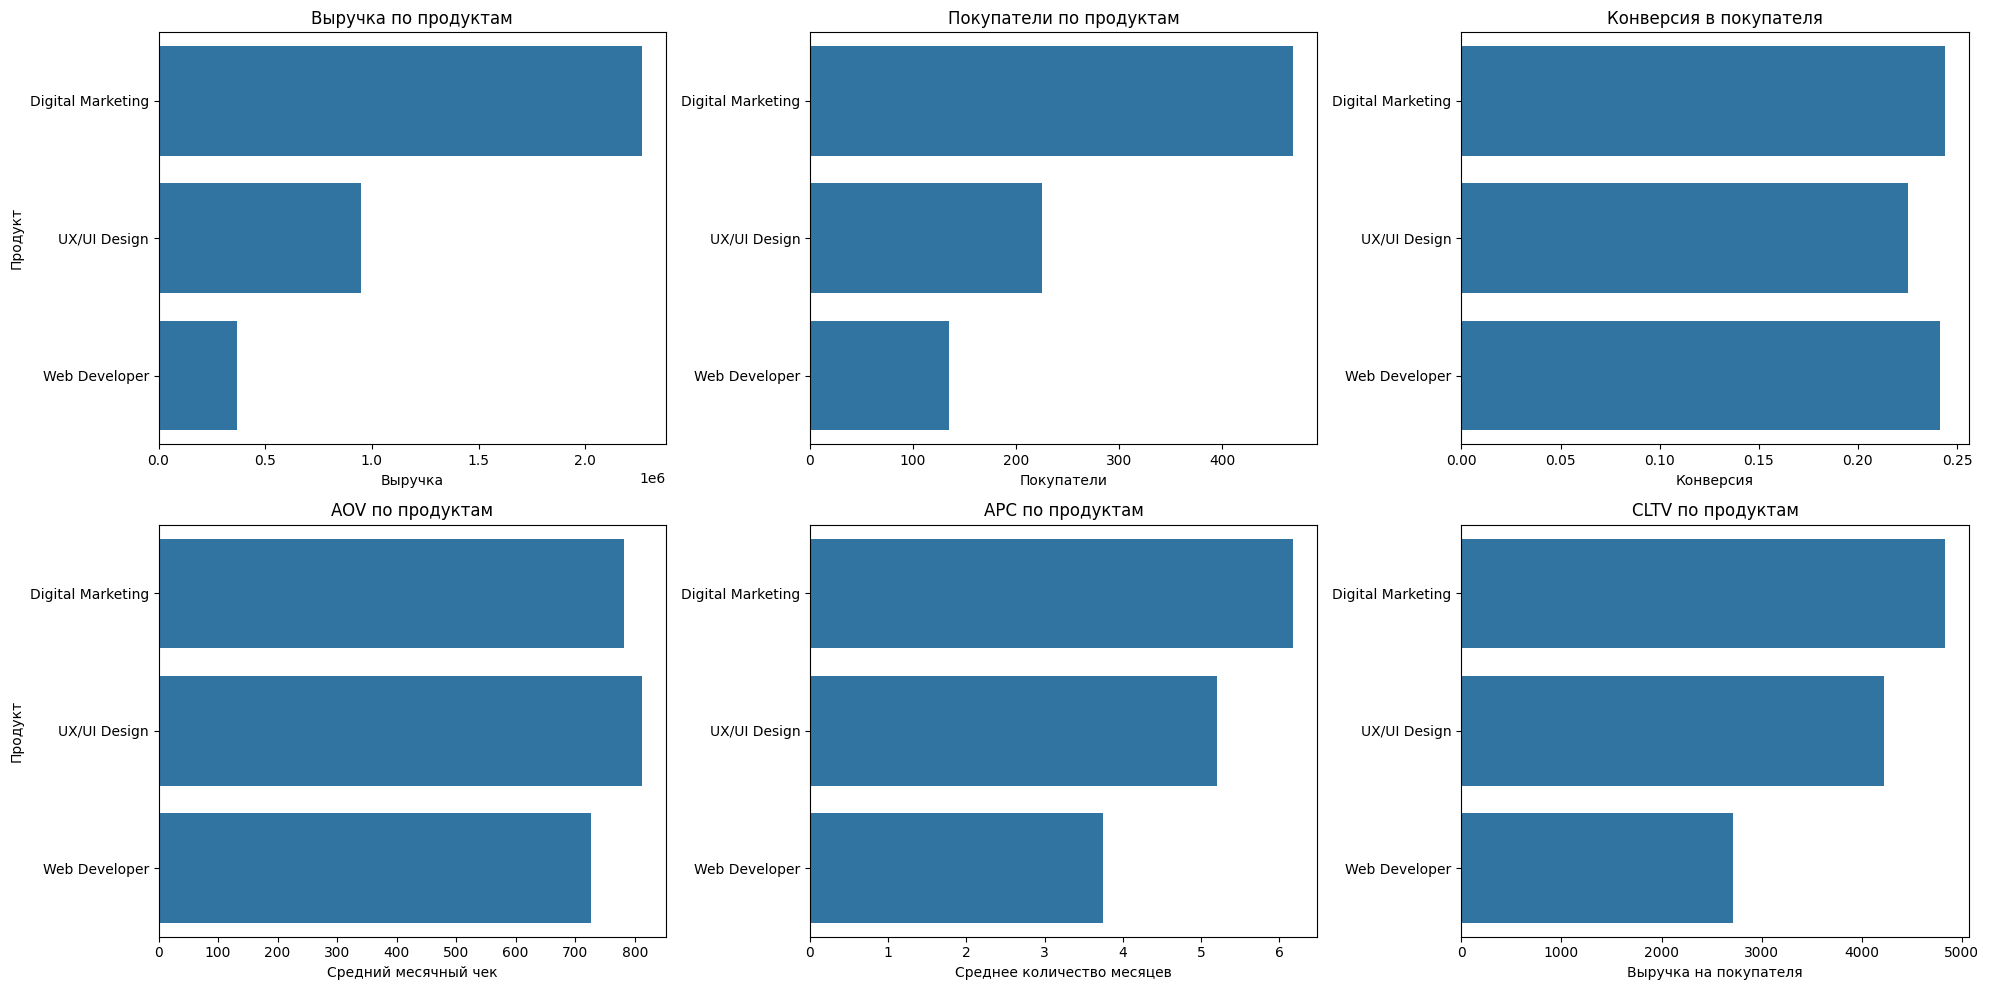

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.barplot(data=product_unit, x="revenue", y="product", ax=axes[0, 0])
axes[0, 0].set_title("Выручка по продуктам")
axes[0, 0].set_xlabel("Выручка")
axes[0, 0].set_ylabel("Продукт")

sns.barplot(data=product_unit, x="buyers", y="product", ax=axes[0, 1])
axes[0, 1].set_title("Покупатели по продуктам")
axes[0, 1].set_xlabel("Покупатели")
axes[0, 1].set_ylabel("")

sns.barplot(data=product_unit, x="c1", y="product", ax=axes[0, 2])
axes[0, 2].set_title("Конверсия в покупателя")
axes[0, 2].set_xlabel("Конверсия")
axes[0, 2].set_ylabel("")

sns.barplot(data=product_unit, x="aov", y="product", ax=axes[1, 0])
axes[1, 0].set_title("AOV по продуктам")
axes[1, 0].set_xlabel("Средний месячный чек")
axes[1, 0].set_ylabel("Продукт")

sns.barplot(data=product_unit, x="apc", y="product", ax=axes[1, 1])
axes[1, 1].set_title("APC по продуктам")
axes[1, 1].set_xlabel("Среднее количество месяцев")
axes[1, 1].set_ylabel("")

sns.barplot(data=product_unit, x="cltv", y="product", ax=axes[1, 2])
axes[1, 2].set_title("CLTV по продуктам")
axes[1, 2].set_xlabel("Выручка на покупателя")
axes[1, 2].set_ylabel("")

plt.tight_layout()
plt.show()

#### CAC по продуктам
CAC по продуктам считать напрямую не получится, потому что рекламные расходы в Spend не привязаны к продукту.
Прямой связи Spend → Product нет, поэтому честный прямой CAC по продуктам невозможен. 

Но можно `попробовать сделать оценочный CAC: распределить расходы кампаний между продуктами пропорционально количеству лидов по source + campaign + product`.

In [50]:
# Считаем, сколько лидов по каждому продукту пришло из каждой связки `source + campaign`.  
# Затем внутри каждой кампании считаем общее количество лидов и долю каждого продукта.  
# Эта доля нужна, чтобы потом распределить рекламные расходы кампании между продуктами.

product_campaign_leads = (analytics_base[~analytics_base["product"].isin(excluded_products)]
    .groupby(["source", "campaign", "product"], dropna=False)
    .agg(product_leads=("id", "count")).reset_index())

product_campaign_leads["campaign_total_leads"] = (product_campaign_leads.groupby(["source", "campaign"])["product_leads"].transform("sum"))

product_campaign_leads["product_lead_share"] = (product_campaign_leads["product_leads"] / product_campaign_leads["campaign_total_leads"])

In [51]:
# Считаем общие рекламные расходы по каждой связке `source + campaign`.  
# Это нужно, чтобы знать, сколько денег было потрачено на каждую рекламную кампанию.
campaign_spend = (spend.groupby(["source", "campaign"], dropna=False).agg(
        campaign_spend=("spend", "sum")).reset_index())    

In [52]:
# Объединяем лиды по продуктам с расходами по рекламным кампаниям.  
# Если по какой-то кампании нет расходов, заменяем пропуск на 0.  
# Затем распределяем расходы кампании между продуктами пропорционально доле лидов каждого продукта.
product_spend_allocated = product_campaign_leads.merge(campaign_spend, on=["source", "campaign"], how="left")

product_spend_allocated["campaign_spend"] = (product_spend_allocated["campaign_spend"].fillna(0))

product_spend_allocated["allocated_spend"] = (product_spend_allocated["campaign_spend"] * product_spend_allocated["product_lead_share"])

In [53]:
# Суммируем распределенные рекламные расходы на уровне продукта.  
# В результате получаем оценочную сумму маркетинговых расходов для каждого продукта.
product_spend = (product_spend_allocated.groupby("product", dropna=False).agg(allocated_spend=("allocated_spend", "sum")).reset_index())    

In [54]:
# Добавляем оценочные рекламные расходы к таблице юнит-экономики продуктов.  
# После этого считаем оценочный CAC и ROMI по продуктам.  
# Эти показатели являются приблизительными, потому что расходы распределены по продуктам через долю лидов, а не через прямую связь в данных.
product_unit = product_unit.merge(product_spend, on="product", how="left")

product_unit["allocated_spend"] = product_unit["allocated_spend"].fillna(0)

product_unit["estimated_cac"] = (product_unit["allocated_spend"] / product_unit["buyers"].replace(0, np.nan)).round(2)

product_unit["estimated_romi"] = ((product_unit["revenue"] - product_unit["allocated_spend"]) 
                                  / product_unit["allocated_spend"].replace(0, np.nan) * 100).round(2)


In [55]:
# И теперь в таблицу можно добавить:
product_unit_formatted = product_unit.copy()

for col in ["c1", "revenue_share", "buyers_share"]:
    product_unit_formatted[col] = (product_unit_formatted[col] * 100).round(2)

round_columns = [
    "revenue",
    "aov",
    "apc",
    "cltv",
    "allocated_spend",
    "estimated_cac",
    "estimated_romi"]

for col in round_columns:
    product_unit_formatted[col] = product_unit_formatted[col].round(2)

product_unit_formatted[[
    "product",
    "users",
    "buyers",
    "c1",
    "revenue",
    "aov",
    "apc",
    "cltv",
    "allocated_spend",
    "estimated_cac",
    "estimated_romi",
    "revenue_share",
    "buyers_share"]]

,product,users,buyers,c1,revenue,aov,apc,cltv,allocated_spend,estimated_cac,estimated_romi,revenue_share,buyers_share
0,Digital Marketing,1924,469.0,24.38,2264850.0,781.79,6.18,4829.10,78131.25,166.59,2798.78,63.24,56.57
1,UX/UI Design,999,225.0,22.52,949945.0,811.92,5.20,4221.98,36507.32,162.25,2502.07,26.52,27.14
2,Web Developer,559,135.0,24.15,366580.0,725.90,3.74,2715.41,31090.16,230.30,1079.09,10.24,16.28


#### Чтобы определить оценочную маркетинговую эффективность продуктов.
Строим дополнительный график с метриками:
- estimated_cac — оценочная стоимость привлечения покупателя;
- estimated_romi — оценочная окупаемость маркетинга.

Так как они отвечают на вопрос - какой продукт дороже привлекать и какой продукт лучше окупается?

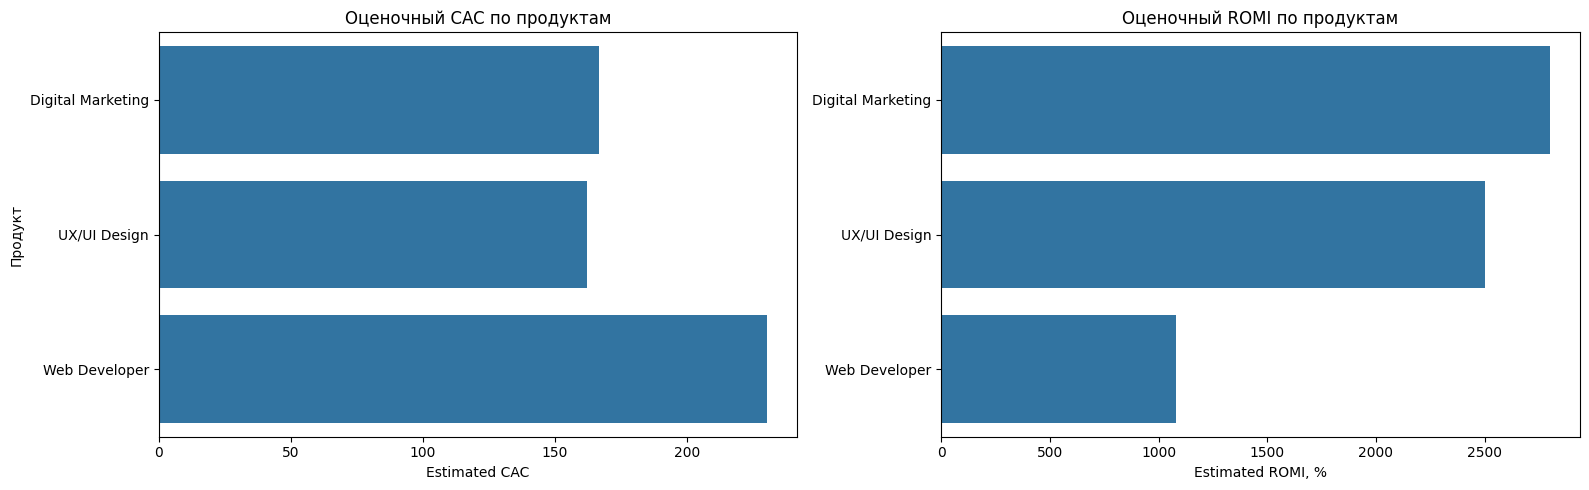

In [58]:
product_order = ["Digital Marketing", "UX/UI Design", "Web Developer"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=product_unit, x="estimated_cac", y="product", order=product_order, ax=axes[0])
axes[0].set_title("Оценочный CAC по продуктам")
axes[0].set_xlabel("Estimated CAC")
axes[0].set_ylabel("Продукт")

sns.barplot(data=product_unit, x="estimated_romi", y="product", order=product_order, ax=axes[1])
axes[1].set_title("Оценочный ROMI по продуктам")
axes[1].set_xlabel("Estimated ROMI, %")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Вывод по юнит-экономике продуктов

Юнит-экономика была рассчитана в разрезе основных продуктов. Из анализа были исключены `Data Analytics`, `Find yourself in IT` и `Unknown`, так как по ним мало данных или они не являются полноценными направлениями для сравнения.

Для каждого продукта были рассчитаны: количество пользователей, количество покупателей, конверсия в покупателя, справедливая выручка, AOV, APC, CLTV, доля выручки и доля покупателей.

AOV был рассчитан по справедливой формуле, которая учитывает первый платеж, стоимость курса, длительность курса и количество месяцев обучения. Это позволяет не ограничиваться только первым платежом, а оценить более реалистичную выручку по студентам.

Так как в таблице рекламных расходов нет прямой связи с продуктом, CAC по продуктам был рассчитан оценочно. Для этого расходы каждой рекламной кампании были распределены между продуктами пропорционально количеству лидов, которые эта кампания привела на каждый продукт.

Полученные `estimated_cac` и `estimated_romi` не являются абсолютно точными финансовыми показателями, но они помогают приблизительно сравнить продукты между собой по стоимости привлечения и окупаемости.

Такой анализ позволяет понять, какие продукты дают основной объем выручки, какие имеют лучшую конверсию, какие приносят больше денег на одного покупателя и какие могут быть дороже в привлечении.

## Анализ чувствительности по продуктам
Мы смотрим не просто “что двигает бизнес в целом”, а какой рычаг роста сильнее для каждого продукта отдельно.

Будем менять по одной метрике:
* +10% users — больше лидов;
* +10% c1 — выше конверсия;
* +10% aov — выше средний чек;
* +10% apc — больше месяцев обучения;
* -10% estimated_cac — дешевле привлечение.

Главная метрика результата: CM = Revenue - Marketing Cost

In [59]:
sensitivity_results = []

delta = 0.10

for _, row in product_unit.iterrows():
    product = row["product"]

    users_base = row["users"]
    c1_base = row["c1"]
    aov_base = row["aov"]
    apc_base = row["apc"]
    cac_base = row["estimated_cac"]

    buyers_base = users_base * c1_base
    revenue_base = buyers_base * apc_base * aov_base
    marketing_cost_base = buyers_base * cac_base
    cm_base = revenue_base - marketing_cost_base

    scenarios = [
        ("База", users_base, c1_base, aov_base, apc_base, cac_base),
        ("+10% Users", users_base * (1 + delta), c1_base, aov_base, apc_base, cac_base),
        ("+10% C1", users_base, c1_base * (1 + delta), aov_base, apc_base, cac_base),
        ("+10% AOV", users_base, c1_base, aov_base * (1 + delta), apc_base, cac_base),
        ("+10% APC", users_base, c1_base, aov_base, apc_base * (1 + delta), cac_base),
        ("-10% CAC", users_base, c1_base, aov_base, apc_base, cac_base * (1 - delta))    ]

    for scenario, users, c1, aov, apc, cac in scenarios:
        buyers = users * c1
        revenue = buyers * apc * aov
        marketing_cost = buyers * cac
        cm = revenue - marketing_cost

        sensitivity_results.append({
            "product": product,
            "scenario": scenario,
            "users": users,
            "c1": c1,
            "aov": aov,
            "apc": apc,
            "cac": cac,
            "buyers": buyers,
            "revenue": revenue,
            "marketing_cost": marketing_cost,
            "cm": cm,
            "delta_cm": cm - cm_base})

product_sensitivity = pd.DataFrame(sensitivity_results)

product_sensitivity

,product,scenario,users,c1,aov,apc,cac,buyers,revenue,marketing_cost,cm,delta_cm
0,Digital Marketing,База,1924.0,0.243763,781.791508,6.176972,166.590,469.0,2264850.0,78130.710,2186719.290,0.000
1,Digital Marketing,+10% Users,2116.4,0.243763,781.791508,6.176972,166.590,515.9,2491335.0,85943.781,2405391.219,218671.929
2,Digital Marketing,+10% C1,1924.0,0.268139,781.791508,6.176972,166.590,515.9,2491335.0,85943.781,2405391.219,218671.929
3,Digital Marketing,+10% AOV,1924.0,0.243763,859.970659,6.176972,166.590,469.0,2491335.0,78130.710,2413204.290,226485.000
4,Digital Marketing,+10% APC,1924.0,0.243763,781.791508,6.794670,166.590,469.0,2491335.0,78130.710,2413204.290,226485.000
5,Digital Marketing,-10% CAC,1924.0,0.243763,781.791508,6.176972,149.931,469.0,2264850.0,70317.639,2194532.361,7813.071
6,UX/UI Design,База,999.0,0.225225,811.918803,5.200000,162.250,225.0,949945.0,36506.250,913438.750,0.000
7,UX/UI Design,+10% Users,1098.9,0.225225,811.918803,5.200000,162.250,247.5,1044939.5,40156.875,1004782.625,91343.875
8,UX/UI Design,+10% C1,999.0,0.247748,811.918803,5.200000,162.250,247.5,1044939.5,40156.875,1004782.625,91343.875
9,UX/UI Design,+10% AOV,999.0,0.225225,893.110684,5.200000,162.250,225.0,1044939.5,36506.250,1008433.250,94994.500


In [60]:
product_sensitivity_pivot = (product_sensitivity[product_sensitivity["scenario"] != "База"]
    .pivot_table(index="product", columns="scenario",  values="delta_cm").reset_index())

product_sensitivity_pivot

scenario,product,+10% AOV,+10% APC,+10% C1,+10% Users,-10% CAC
0,Digital Marketing,226485.0,226485.0,218671.929,218671.929,7813.071
1,UX/UI Design,94994.5,94994.5,91343.875,91343.875,3650.625
2,Web Developer,36658.0,36658.0,33548.950,33548.950,3109.050


In [61]:
product_sensitivity_pivot_formatted = product_sensitivity_pivot.copy()

scenario_columns = [
    col for col in product_sensitivity_pivot_formatted.columns
    if col != "product"]

for col in scenario_columns:
    product_sensitivity_pivot_formatted[col] = (product_sensitivity_pivot_formatted[col].round(2))

product_sensitivity_pivot_formatted

scenario,product,+10% AOV,+10% APC,+10% C1,+10% Users,-10% CAC
0,Digital Marketing,226485.0,226485.0,218671.93,218671.93,7813.07
1,UX/UI Design,94994.5,94994.5,91343.88,91343.88,3650.62
2,Web Developer,36658.0,36658.0,33548.95,33548.95,3109.05


### Графическое отображение анализа чувствительности продуктов

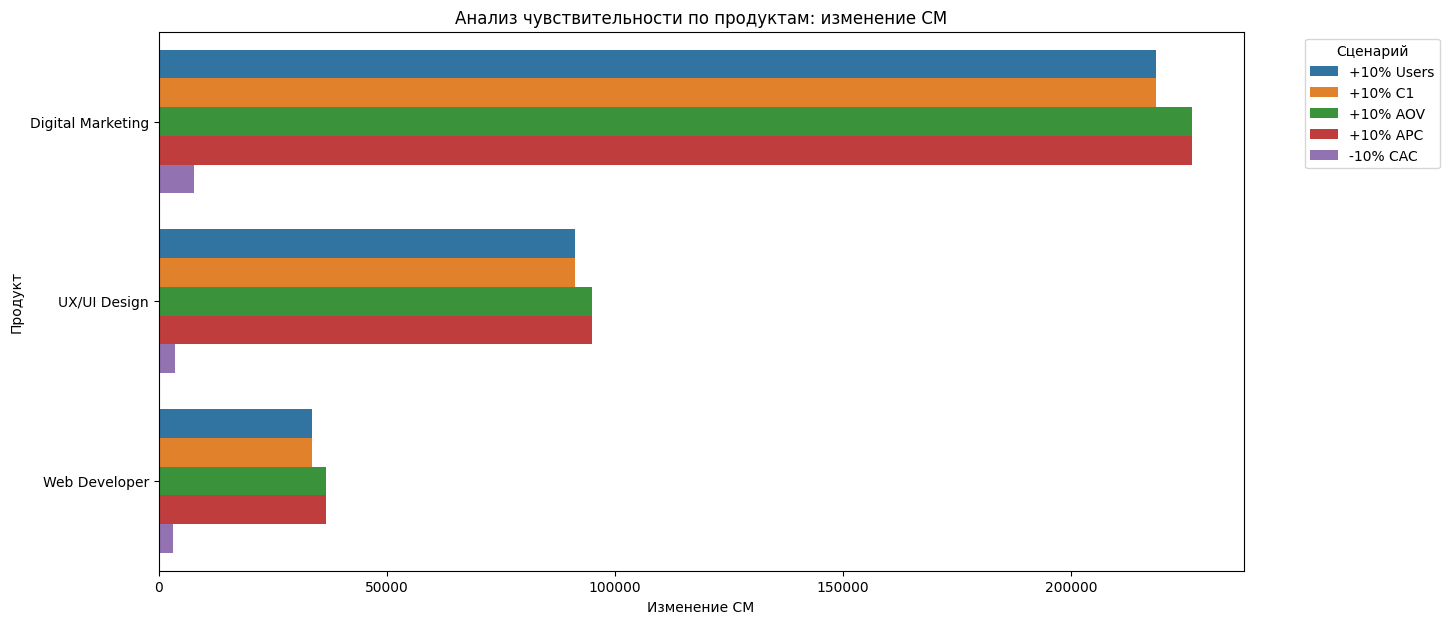

In [62]:
product_sensitivity_plot = product_sensitivity[
    product_sensitivity["scenario"] != "База"].copy()

plt.figure(figsize=(14, 7))

sns.barplot(data=product_sensitivity_plot, x="delta_cm", y="product", hue="scenario", order=product_order)

plt.title("Анализ чувствительности по продуктам: изменение CM")
plt.xlabel("Изменение CM")
plt.ylabel("Продукт")
plt.legend(title="Сценарий", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

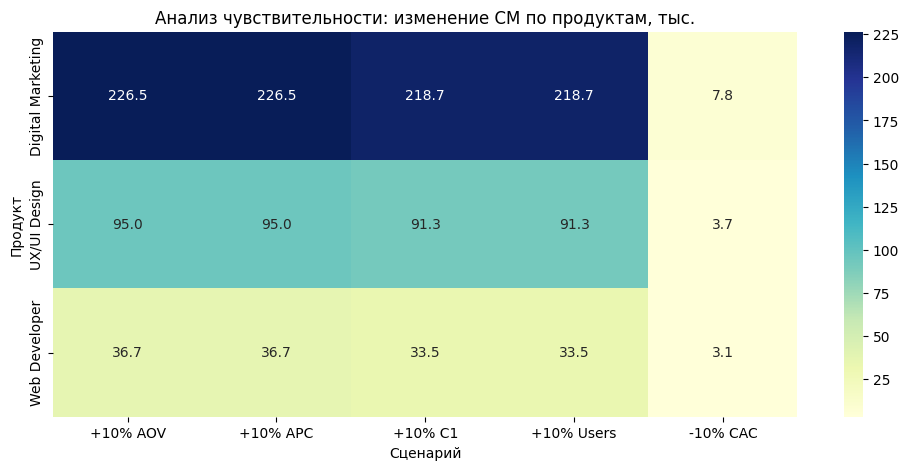

In [64]:
sensitivity_heatmap_k = (product_sensitivity_pivot.set_index("product") / 1000)

plt.figure(figsize=(12, 5))

sns.heatmap(sensitivity_heatmap_k, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title("Анализ чувствительности: изменение CM по продуктам, тыс.")
plt.xlabel("Сценарий")
plt.ylabel("Продукт")
plt.show()

## Вывод по анализу чувствительности продуктов

Анализ чувствительности был проведен по основным продуктам. Для каждого продукта были смоделированы изменения ключевых рычагов: рост количества лидов, рост конверсии, рост среднего чека, рост количества платежных периодов и снижение стоимости привлечения.

В качестве результата оценивалось изменение `CM` — разницы между справедливой выручкой и оценочными маркетинговыми расходами.

Такой анализ помогает понять, какой рычаг роста потенциально сильнее для каждого продукта. Это важно, потому что разные продукты могут иметь разные точки роста: для одного продукта важнее увеличить конверсию, для другого — средний чек, для третьего — снизить стоимость привлечения.

Этот блок может быть использован как основа для выбора более точной гипотезы не только по бизнесу в целом, но и по конкретному направлению обучения.

Единственное, что мы не можем учесть - это стоимость внесения изменения метрик на 10% (т.е это либо прямая финансовая стоимость(стоимость рекламмы), улучшение технической работы СRM (зарплата програмистам и их время для внесения изменений))... Т.е. по умолчанию принимаем что все действия по изменению метрик на 10% - это приблизительно одинаковая стоимость для компании.

## Дерево метрик юнит-экономики

Главной метрикой выбрана `CM` — contribution margin, то есть разница между справедливой выручкой и маркетинговыми расходами.

`CM = Rev - AC`

Где:

`Rev` — справедливая выручка по студентам.  
`AC` — маркетинговые расходы.

Дальше ключевые формулы дерева:

`Rev = UA × C1 × APC × AOV`

`AC = UA × CPL`

`CLTV = AOV × APC`

`LTV = C1 × CLTV`

`CAC = AC / B`

`CPL = AC / UA`

`C1 = B / UA`

`AOV = Rev / T`

`APC = T / B`

Атомный уровень строится на сырых данных из таблиц:

- `contacts.id` — для расчета `UA`;
- `contact_id` и `is_student` — для расчета `B`;
- `months_of_study` — для расчета `T`;
- `initial_amount_paid`, `offer_total_amount`, `course_duration`, `months_of_study` — для расчета справедливой выручки `Rev`;
- `spend` — для расчета маркетинговых расходов `AC`.

In [70]:
def add_box(ax, x, y, text, width=2.5, height=0.65, color="#E8F1FA", fontsize=9):
    box = FancyBboxPatch((x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.04",
        linewidth=1.1,
        edgecolor="#2F4858",
        facecolor=color)
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)

def add_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2 + 0.35), xytext=(x1, y1 - 0.35), arrowprops=dict(arrowstyle="->", linewidth=1, color="#2F4858"))

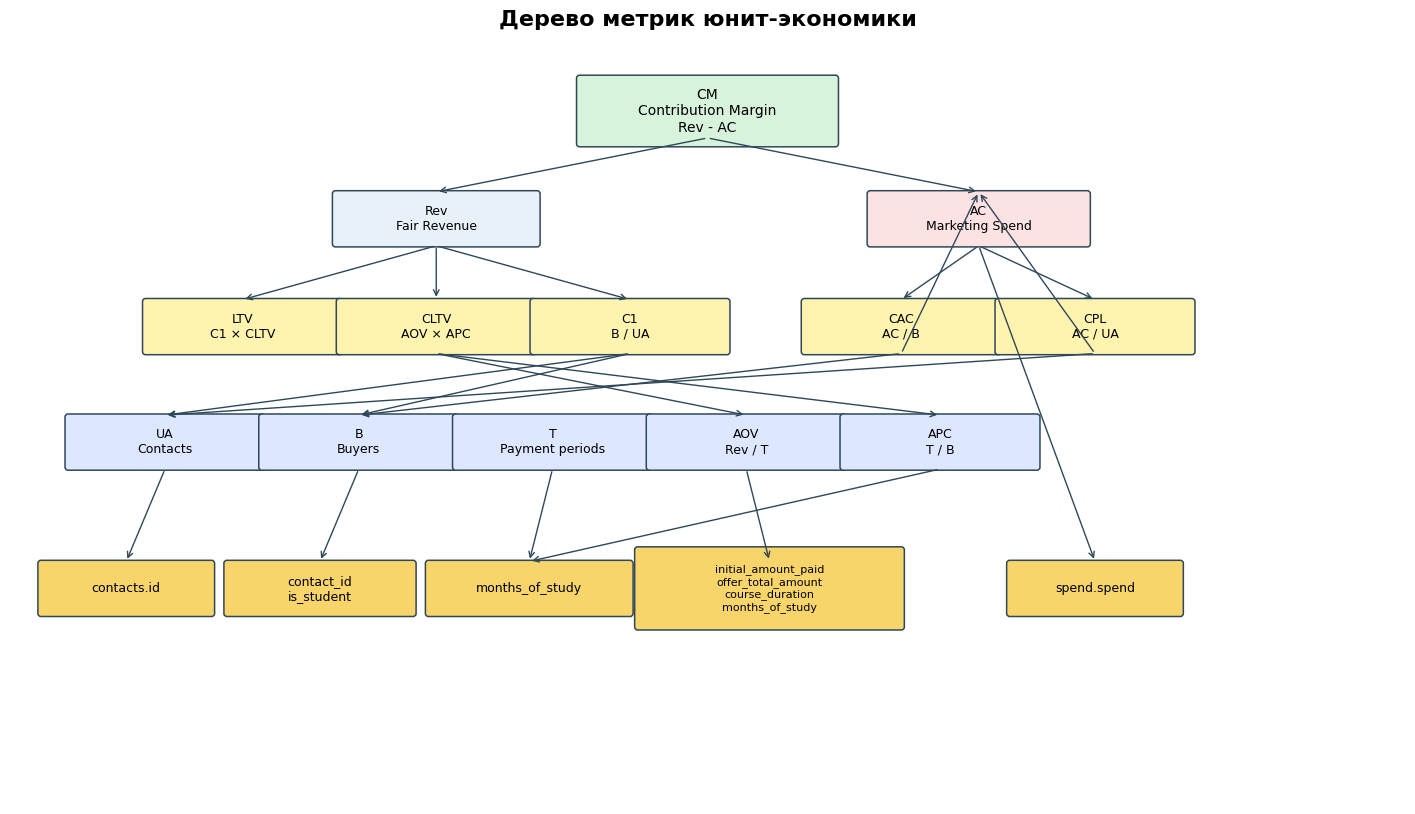

In [71]:
fig, ax = plt.subplots(figsize=(18, 10))

ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis("off")

# Уровень 1: ключевая метрика
add_box(ax, 9, 9, "CM\nContribution Margin\nRev - AC", width=3.3, height=0.85, color="#D8F3DC", fontsize=10)

# Уровень 2: финансовые показатели
add_box(ax, 5.5, 7.6, "Rev\nFair Revenue", width=2.6, color="#E8F1FA")

add_box(ax, 12.5, 7.6, "AC\nMarketing Spend", width=2.8, color="#FDE2E4")

# Уровень 3: decision metrics
add_box(ax, 3, 6.2, "LTV\nC1 × CLTV", color="#FFF3B0")
add_box(ax, 5.5, 6.2, "CLTV\nAOV × APC", color="#FFF3B0")
add_box(ax, 8, 6.2, "C1\nB / UA", color="#FFF3B0")
add_box(ax, 11.5, 6.2, "CAC\nAC / B", color="#FFF3B0")
add_box(ax, 14, 6.2, "CPL\nAC / UA", color="#FFF3B0")

# Уровень 4: unit metrics
add_box(ax, 2, 4.7, "UA\nContacts", color="#DDE7FF")
add_box(ax, 4.5, 4.7, "B\nBuyers", color="#DDE7FF")
add_box(ax, 7, 4.7, "T\nPayment periods", color="#DDE7FF")
add_box(ax, 9.5, 4.7, "AOV\nRev / T", color="#DDE7FF")
add_box(ax, 12, 4.7, "APC\nT / B", color="#DDE7FF")

# Уровень 5: сырые данные
add_box(ax, 1.5, 2.8, "contacts.id", width=2.2, color="#F8D56B")
add_box(ax, 4, 2.8, "contact_id\nis_student", width=2.4, color="#F8D56B")
add_box(ax, 6.7, 2.8, "months_of_study", width=2.6, color="#F8D56B")
add_box(ax, 9.8, 2.8, "initial_amount_paid\noffer_total_amount\ncourse_duration\nmonths_of_study", width=3.4, height=1.0, color="#F8D56B", fontsize=8)
add_box(ax, 14, 2.8, "spend.spend", width=2.2, color="#F8D56B")

# Стрелки: верхний уровень
add_arrow(ax, 9, 9, 5.5, 7.6)
add_arrow(ax, 9, 9, 12.5, 7.6)

# Rev к метрикам
add_arrow(ax, 5.5, 7.6, 3, 6.2)
add_arrow(ax, 5.5, 7.6, 5.5, 6.2)
add_arrow(ax, 5.5, 7.6, 8, 6.2)

# AC к метрикам
add_arrow(ax, 12.5, 7.6, 11.5, 6.2)
add_arrow(ax, 12.5, 7.6, 14, 6.2)

# Decision metrics к unit metrics
add_arrow(ax, 8, 6.2, 2, 4.7)
add_arrow(ax, 8, 6.2, 4.5, 4.7)

add_arrow(ax, 5.5, 6.2, 9.5, 4.7)
add_arrow(ax, 5.5, 6.2, 12, 4.7)

add_arrow(ax, 11.5, 6.2, 12.5, 7.6)
add_arrow(ax, 11.5, 6.2, 4.5, 4.7)

add_arrow(ax, 14, 6.2, 12.5, 7.6)
add_arrow(ax, 14, 6.2, 2, 4.7)

# Unit metrics к атомным данным
add_arrow(ax, 2, 4.7, 1.5, 2.8)
add_arrow(ax, 4.5, 4.7, 4, 2.8)
add_arrow(ax, 7, 4.7, 6.7, 2.8)
add_arrow(ax, 9.5, 4.7, 9.8, 2.8)
add_arrow(ax, 12, 4.7, 6.7, 2.8)
add_arrow(ax, 12.5, 7.6, 14, 2.8)

plt.title("Дерево метрик юнит-экономики", fontsize=16, fontweight="bold")
plt.show()

### Вывод по дереву метрик

В дереве метрик главной бизнес-метрикой была выбрана `CM` — contribution margin, то есть разница между справедливой выручкой и маркетинговыми расходами.

`CM = Rev - AC`

Такой выбор логичен, потому что для бизнеса важно не только получить выручку, но и понимать, сколько остается после затрат на привлечение клиентов.

Дерево показывает, что на `CM` влияют две основные части:

`Rev` — справедливая выручка;

`AC` — маркетинговые расходы.

Выручка раскладывается через формулу:

`Rev = UA × C1 × APC × AOV`

Где:

`UA` — количество привлеченных лидов / контактов;  
`C1` — конверсия из лида в покупателя;  
`APC` — среднее количество платежных периодов;  
`AOV` — средний месячный чек.

Маркетинговые расходы можно представить как:

`AC = UA × CPL`

Где:

`CPL` — стоимость привлечения одного лида.

Таким образом, основные рычаги роста `CM`:

- увеличить `UA`, то есть привлечь больше лидов;
- увеличить `C1`, то есть лучше конвертировать лидов в студентов;
- увеличить `AOV`, то есть повысить средний месячный чек;
- увеличить `APC`, то есть увеличить длительность обучения / количество платежных периодов;
- снизить `CPL`, то есть уменьшить стоимость привлечения лида.

Для дальнейшей гипотезы наиболее важным рычагом выбран `C1`, потому что он напрямую связан с качеством обработки лидов и может быть улучшен без изменения цены продукта и без увеличения рекламного бюджета.

# Построение ОСНОВНОЙ ГИПОТИЗЫ

# Основная гипотеза

## HADI-цикл для выбранной гипотезы

### HADI-цикл

| Этап | Описание |
|---|---|
| H — Hypothesis / Гипотеза | Если после неуспешного первого звонка отправлять клиенту автоматическое SMS и делать повторный звонок в течение часа, то увеличится доля успешных контактов, а затем и конверсия из лида в студента. |
| A — Action / Действие | Для тестовой группы запускаем новый сценарий: если клиент не ответил на первый звонок, система автоматически отправляет SMS, а менеджер делает повторный звонок в течение часа. В контрольной группе процесс остается без изменений. |
| D — Data / Данные | Основная прокси-метрика: доля лидов с успешным контактом. Финальная бизнес-метрика: `C1` из лида в студента. Дополнительно отслеживаем SLA, количество повторных звонков, количество студентов, справедливую выручку и `CM`. |
| I — Insights / Анализ | Если в тестовой группе растет доля успешных контактов и не ухудшается `C1`, гипотеза частично подтверждается. Если растет и доля успешных контактов, и `C1`, гипотеза подтверждается полностью. Если изменений нет, сценарий повторного касания не дал эффекта. 
|
### Нулевая гипотеза

Изменение процесса первого контакта с лидом не влияет на конверсию `C1` из лида в студента.

### Обоснование выбора гипотезы

1. В бизнес-анализе самая значительная группа причин потерь — `Нет контакта / проблема связи` — 37,77%. Следующая крупная группа — `Причина не указана` — 24,91%, остальные причины имеют меньший удельный вес. Это показывает, что проблема контакта с лидом является одной из основных зон потерь.

2. В юнит-экономике конверсия `C1` оказалась сопоставимой для трех основных продуктов. Это значит, что работа с первым контактом может быть универсальной точкой роста не для одного отдельного направления, а для всей продуктовой линейки.

3. Анализ чувствительности показал, что изменение `C1` заметно влияет на `CM`. По силе влияния на `CM` рост конверсии находится среди наиболее значимых рычагов и уступает в основном ценовым метрикам: увеличению среднего чека или количества платежных периодов. Это видно на тепловой карте и графике анализа чувствительности продуктов.

4. На первый контакт с клиентом можно влиять без изменения цены продукта и рекламного бюджета. Это важно, потому что изменение цены может вызвать негативную реакцию клиентов, а рост рекламных расходов увеличивает нагрузку на бюджет. Улучшение первого контакта можно реализовать технически, например автоматическим сообщением, или организационно, например обязательным повторным звонком через час.

5. Гипотеза напрямую связана с деревом метрик: улучшение первого контакта должно повысить долю успешных контактов, затем увеличить `C1`, а рост `C1` ведет к росту `Revenue`, `LTV` и `CM`.

# Условия проведения A/B-теста

### Гипотеза для A/B-тестирования

Изменение процесса первого контакта с лидом: если первый звонок неуспешный, то в течение часа клиенту отправляется автоматическое SMS и менеджер делает повторный звонок, что увеличит конверсию `C1` из лида в студента.

### Нулевая гипотеза

Изменение процесса первого контакта с лидом не влияет на конверсию `C1` из лида в студента.

### Количество групп

Для тестирования необходимо 2 группы:

1. `Control` — текущий процесс обработки лида.
2. `Test` — улучшенный процесс первого контакта.

Новые лиды распределяются между группами случайно в пропорции 50/50.

### Кто участвует в тесте

В тест включаются новые лиды, которые оставили заявку после запуска эксперимента.

Из теста исключаются:

- старые лиды;
- дубли;
- лиды без контактного номера;
- клиенты, которые уже начали обучение до запуска теста.

### Главная метрика

Главная метрика теста — `C1`.

`C1 = Buyers / UA`

То есть конверсия из лида в студента.

### Вторичные метрики

Дополнительно отслеживаются:

- доля успешных контактов;
- среднее SLA;
- доля лидов, с которыми удалось связаться в первый день;
- количество повторных звонков;
- количество студентов;
- справедливая выручка;
- `CM`.

Вторичные метрики нужны, чтобы понять механизм влияния. Если сначала растет доля успешных контактов, а затем растет `C1`, это подтверждает логику гипотезы.

# Расчет размера выборки

In [85]:
# Размер выборки рассчитывается по формуле:
# `n = (16 × p × (1 - p)) / x²`
# где:
# `p` — базовая конверсия `C1`;  

# `x` — минимально обнаруживаемый эффект. Для финальной метрики `C1` эффект в x = 1 п.п. требует слишком большой выборки. 
    #Поэтому для учебного расчета и предварительной оценки выбран более крупный минимально обнаруживаемый эффект x = 5 п.п.. 
    # При этом финальная метрика `C1` остается стратегической, а для более быстрого тестирования используется продуктовая прокси-метрика — доля успешных контактов.  

# `n` — необходимое количество лидов в каждой группе.

# Для расчета размера выборки использовалась общая конверсия `C1` из лида в студента: 828 уникальных студентов из 18 510 уникальных контактов, то есть 4,47%.
# При минимально обнаруживаемом эффекте 1 п.п. по формуле `n = (16 × p × (1 - p)) / x²` необходимо около 6 838 лидов в каждую группу. Всего для проведения A/B-теста потребуется около 13 675 лидов.
# Для расчета использовались отдельные переменные с префиксом `ab_`, чтобы не смешивать общую конверсию с продуктовыми метриками из предыдущих блоков.

ab_ua = contacts["id"].nunique()
ab_buyers = (analytics_base[analytics_base["is_student"] == True]["contact_id"].nunique())
ab_test_p = ab_buyers / ab_ua

x = 0.05
n_per_group = (16 * ab_test_p * (1 - ab_test_p)) / (x ** 2)
n_total = n_per_group * 2

print("UA:", ab_ua)
print("Buyers:", ab_buyers)
print("Базовая конверсия C1:", round(ab_test_p * 100, 2), "%")
print("Минимально обнаруживаемый эффект:", round(x * 100, 2), "%")
print("Размер одной группы:", int(np.ceil(n_per_group)))
print("Всего лидов для A/B-теста:", int(np.ceil(n_total)))

UA: 18510
Buyers: 828
Базовая конверсия C1: 4.47 %
Минимально обнаруживаемый эффект: 5.0 %
Размер одной группы: 274
Всего лидов для A/B-теста: 547


## Оценка длительности теста

In [84]:
# Чтобы оценить длительность теста, считаем среднее количество новых лидов в день по историческим данным. Затем делим необходимое количество лидов для теста на средний дневной поток лидов.
# Это приблизительная оценка: фактическая длительность теста может отличаться из-за сезонности, изменений рекламного бюджета и качества трафика.

analytics_base["created_time"] = pd.to_datetime(analytics_base["created_time"], errors="coerce")

date_min = analytics_base["created_time"].min()
date_max = analytics_base["created_time"].max()

days_in_data = (date_max - date_min).days + 1

avg_daily_leads = analytics_base["id"].count() / days_in_data

test_duration_days = n_total / avg_daily_leads

print("Период данных:", date_min.date(), "-", date_max.date())
print("Количество дней в данных:", days_in_data)
print("Среднее количество лидов в день:", round(avg_daily_leads, 2))
print("Оценочная длительность теста, дней:", int(np.ceil(test_duration_days)))

Период данных: 2023-07-03 - 2024-06-21
Количество дней в данных: 354
Среднее количество лидов в день: 56.0
Оценочная длительность теста, дней: 10


#### Для финальной метрики `C1` эффект в 1 п.п. требует слишком большой выборки. Поэтому для учебного расчета и предварительной оценки выбран более крупный минимально обнаруживаемый эффект. При этом финальная метрика `C1` остается стратегической, а для более быстрого тестирования используется продуктовая прокси-метрика — доля успешных контактов.

### Помимо C1 верхнего уровня спускаемся на продуктовый слой: конверсия лида в успешный контакт, что безусловно поможет понять влияние нашей гипотизы на коверсию как общую, так и продуктового уровня.
C1_total = Students / Leads
proxy_C1_contact = Leads with successful contact / Leads

In [78]:
analytics_base["has_successful_call"] = (analytics_base["successful_calls"] > 0)

proxy_p = analytics_base["has_successful_call"].mean()

In [91]:
proxy_x = 0.05

proxy_n_per_group = (16 * proxy_p * (1 - proxy_p)) / (proxy_x ** 2)

proxy_n_total = proxy_n_per_group * 2

proxy_test_duration_days = proxy_n_total / avg_daily_leads

print("Базовая доля успешного контакта:", round(proxy_p * 100, 2), "%")
print("Минимально обнаруживаемый эффект:", round(proxy_x * 100, 2), "%")
print("Размер одной группы:", int(np.ceil(proxy_n_per_group)))
print("Всего лидов для A/B-теста:", int(np.ceil(proxy_n_total)))
print("Оценочная длительность теста, дней:", int(np.ceil(proxy_test_duration_days)))

Базовая доля успешного контакта: 79.65 %
Минимально обнаруживаемый эффект: 5.0 %
Размер одной группы: 1038
Всего лидов для A/B-теста: 2076
Оценочная длительность теста, дней: 38


### Стоимость SMS
Учитывая что нам предстоит автоматически отправлять смс, а это деньги, то можем немного проанализировать сколько это нам будет стить

In [89]:
sms_cost_eur = 0.10

test_group_size = int(np.ceil(proxy_n_per_group))

sms_total_cost = test_group_size * sms_cost_eur

print("Размер тестовой группы:", test_group_size)
print("Стоимость одного SMS:", sms_cost_eur)
print("Оценочная стоимость SMS для тестовой группы:", round(sms_total_cost, 2))

Размер тестовой группы: 1038
Стоимость одного SMS: 0.1
Оценочная стоимость SMS для тестовой группы: 103.8


Так как тестовый сценарий включает автоматическое SMS, у него появляется небольшая дополнительная переменная стоимость. При условной стоимости одного SMS 0.10 евро и размере тестовой группы около N лидов дополнительные расходы составят около N × 0.10 евро.

На фоне положительной окупаемости маркетинга эта сумма не является критичной, но ее нужно учитывать при расчете итогового эффекта теста.

### Вывод
Финальная метрика `C1` остается главной бизнес-метрикой, потому что именно она влияет на `Revenue`, `LTV` и `CM`. Однако выбранное изменение процесса напрямую влияет не сразу на оплату, а на предыдущий слой воронки — успешный контакт с лидом.

Поэтому A/B-тест оценивается на двух уровнях:

1. продуктовый/операционный слой — конверсия лида в успешный контакт;
2. бизнес-слой — конверсия лида в студента `C1`.

Такой подход позволяет быстрее проверить, работает ли изменение процесса первого контакта, и при этом сохранить связь с итоговой юнит-экономикой.

# Интерпретация результатов A/B-теста

## Интерпретация результатов A/B-теста

В данном тесте важно оценивать результат на двух уровнях.

Первый уровень — операционная прокси-метрика: доля лидов с успешным контактом.  
Именно на нее напрямую влияет тестовое изменение: автоматическое SMS после неуспешного первого звонка и повторный звонок в течение часа.

Второй уровень — бизнес-метрика `C1`: конверсия из лида в студента.  
Эта метрика важна для юнит-экономики, так как она влияет на `Revenue`, `LTV` и `CM`.

### Если результат положительный

Если в тестовой группе выросла доля успешных контактов и одновременно выросла или не ухудшилась конверсия `C1`, гипотезу можно считать подтвержденной.

В этом случае новый процесс первого контакта можно масштабировать на всех менеджеров и основные продукты. Дополнительные расходы на SMS нужно учитывать, но при положительном эффекте на конверсию и `CM` эти затраты могут быть экономически оправданы.

### Если выросла только прокси-метрика

Если в тестовой группе выросла доля успешных контактов, но `C1` не изменилась, это означает, что новый сценарий помогает связаться с клиентами, но сам по себе не приводит к росту продаж.

В таком случае гипотеза подтверждается только частично. Следующим шагом нужно анализировать качество разговора, скрипты менеджеров, оффер и причины отказа после успешного контакта.

### Если результат отрицательный

Если доля успешных контактов не выросла или снизилась, гипотеза не подтверждается. Нужно проверить, корректно ли работает автоматическое SMS, не слишком ли быстро или навязчиво происходит повторный контакт, а также не создает ли новый процесс дополнительную нагрузку на менеджеров.

Если при этом снизилась `C1`, тестовый сценарий не стоит масштабировать.

### Если результат статистически незначимый

Если различия между контрольной и тестовой группой небольшие, тест нельзя считать доказательством эффекта.

В таком случае можно:

- продлить тест;
- изменить текст автоматического сообщения;
- протестировать другой интервал повторного звонка;
- отдельно проверить эффект по продуктам или источникам трафика;
- увеличить минимально обнаруживаемый эффект, если бизнесу важны только более крупные изменения.

### Связь с деревом метрик

Тест напрямую направлен на нижний операционный слой воронки — конверсию лида в успешный контакт.

Если этот слой улучшается, у бизнеса появляется больше обработанных лидов, которые потенциально могут перейти в студентов. Дальше это должно повлиять на бизнес-метрику `C1`.

По дереву метрик:

`Rev = UA × C1 × APC × AOV`

Если `C1` растет, то при прочих равных растут `Revenue`, `CLTV`, `LTV` и `CM`.

Таким образом, A/B-тест проверяет не только операционное улучшение процесса продаж, но и его связь с итоговой юнит-экономикой бизнеса.

## Итоговый вывод по юнит-экономике

В рамках блока юнит-экономики была построена общая модель бизнеса и модель в разрезе основных продуктов. На финансовом уровне метрикой принятия решения выбрана CM — contribution margin: разница между справедливой выручкой и маркетинговыми расходами.

Справедливая выручка была рассчитана с учетом первого платежа, полной стоимости курса, длительности курса и количества месяцев обучения. Такой подход позволяет не ограничиваться только первым платежом, а более корректно оценить выручку по студентам.

Общая юнит-экономика показала, что маркетинговые расходы окупаются: ROMI положительный, а CLTV выше CAC. Это означает, что в среднем привлеченный студент приносит больше денег, чем стоит его привлечение.

На продуктовом слое метрик были проанализированы основные направления обучения. Для них были рассчитаны C1, AOV, APC, CLTV, оценочный CAC и оценочный ROMI. Продукты Data Analytics, Find yourself in IT и Unknown были исключены из продуктового сравнения, так как по ним мало данных или они не являются полноценными направлениями для анализа.

Так как в таблице рекламных расходов нет прямой связи с продуктом, CAC и ROMI по продуктам были рассчитаны оценочно: расходы рекламных кампаний были распределены между продуктами пропорционально количеству лидов. Эти показатели нельзя считать абсолютно точными, но они помогают сравнить продукты между собой и увидеть потенциально более сильные и более дорогие направления.

Анализ чувствительности показал, какие рычаги сильнее всего влияют на CM в разрезе продуктов. Среди ключевых рычагов были рассмотрены рост количества лидов, рост конверсии C1, рост среднего чека AOV, рост количества платежных периодов APC и снижение стоимости привлечения.

На основе дерева метрик видно, что CM можно улучшать через рост UA, C1, AOV, APC или снижение CPL. Для дальнейшей гипотезы выбран рычаг C1, так как он связан с одной из главных проблем, найденных в бизнес-анализе: большой долей потерь из-за отсутствия контакта с клиентом.
Сформулированная гипотеза предполагает изменение конкретного процесса первого контакта: если клиент не ответил на первый звонок, ему отправляется автоматическое SMS, а менеджер делает повторный звонок в течение часа. Это изменение направлено прежде всего на операционную продуктовую метрику — долю лидов с успешным контактом. Далее оценивается его влияние на бизнес-метрику C1 — конверсию из лида в студента.

Нулевая гипотеза (H0) состоит в том, что новый сценарий первого контакта не изменяет долю успешных контактов и конверсию C1. Поскольку A/B-тест еще не проведен, нулевая гипотеза пока не отклонена, а альтернативная гипотеза не считается подтвержденной.

Важно, что тестируемое изменение не требует изменения цены продукта или увеличения рекламного бюджета. При этом автоматическое SMS создает небольшую дополнительную переменную стоимость, которую необходимо учитывать при оценке результата теста.

Для проверки гипотезы был описан A/B-тест с двумя группами: контрольной и тестовой. Финальной бизнес-метрикой остается C1, но основной операционной метрикой теста выбрана доля лидов с успешным контактом. Такой подход позволяет спуститься с общего уровня конверсии в студента на более ранний слой воронки и быстрее проверить, работает ли изменение процесса первого контакта.

Рост C1 сам по себе не означает автоматический рост CLTV, так как CLTV отражает среднюю ценность уже привлеченного покупателя. Финансовый эффект для CM появится только в случае, если дополнительная выручка от новых студентов превысит стоимость SMS и повторных контактов, а AOV и APC не ухудшатся. Именно поэтому CM остается метрикой принятия решения о масштабировании изменения.

Таким образом, юнит-экономика подтвердила, что бизнес в целом окупает маркетинговые расходы, а основной потенциал роста находится не только в увеличении рекламы или изменении цены, но и в улучшении обработки текущего потока лидов. Выбранный A/B-тест позволит проверить, дает ли новый сценарий первого контакта статистически значимый рост операционной метрики и C1, а затем принять решение о масштабировании по влиянию на CM.